In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look at the data
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
df.head()
# # ```

# # ---

# # ## ✅ You Should See
# # ```
# Shape: (7043, 21)

# Column Names:
# ['customerID', 'gender', 'SeniorCitizen', 'Partner', 
# 'Dependents', 'tenure', 'PhoneService', ...]

Matplotlib is building the font cache; this may take a moment.


Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Check basic info
print("Total Customers:", len(df))
print("\nMissing Values:")
print(df.isnull().sum())
print("\nChurn Count:")
print(df['Churn'].value_counts())


# ## ✅ You Should See
# ```
# Total Customers: 7043

# Missing Values:
# customerID      0
# gender          0
# ...

# Churn Count:
# No     5174
# Yes    1869
# "Out of 7043 customers, 1869 left the company (churned) and 5174 stayed. No missing values — data is clean."

Total Customers: 7043

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn Count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
# Fix TotalCharges column (it has spaces instead of numbers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the few rows with missing values
df.dropna(inplace=True)

# Convert Churn to numbers (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Confirm
print("Cleaned Shape:", df.shape)
print("Churn column sample:", df['Churn'].value_counts())

"The TotalCharges column had blank spaces instead of numbers — we fixed that. We also converted Yes/No churn into 1/0 so Python can analyse it mathematically."

Cleaned Shape: (7032, 21)
Churn column sample: Churn
0    5163
1    1869
Name: count, dtype: int64


Overall Churn Rate: 26.58%


C:\Users\Admin\AppData\Local\Temp\ipykernel_2528\1743140421.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])


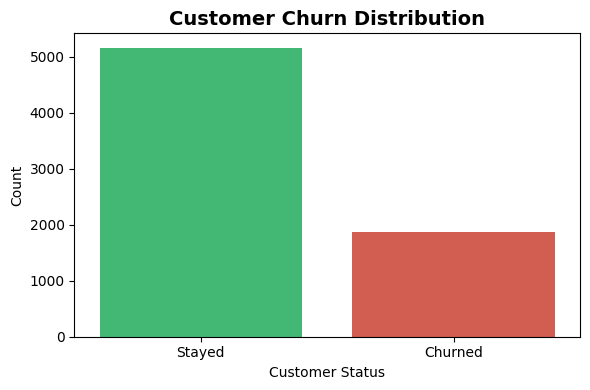

Chart saved!


In [ ]:
# Calculate churn rate
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# Plot churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()
print("Chart saved!")
# "About 1 in 4 customers are leaving the company. This is the core business problem we're solving — find out WHY they're leaving."

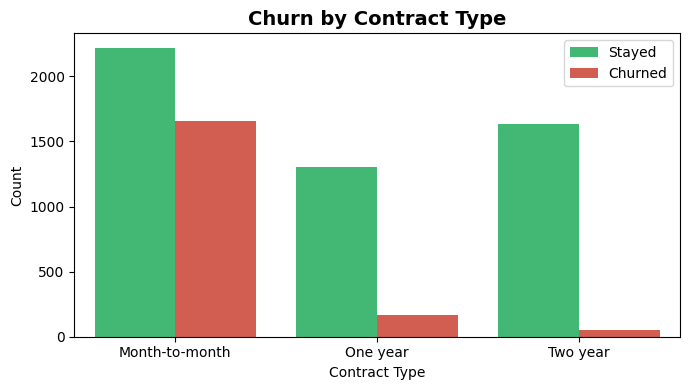

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


In [6]:
# Contract type vs churn
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df, 
              palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

# Print numbers
print(df.groupby('Contract')['Churn'].mean() * 100)
# "Customers on monthly contracts churn at 42% — 15x more than customers on 2-year contracts. Locking customers into longer contracts is the single biggest way to reduce churn."

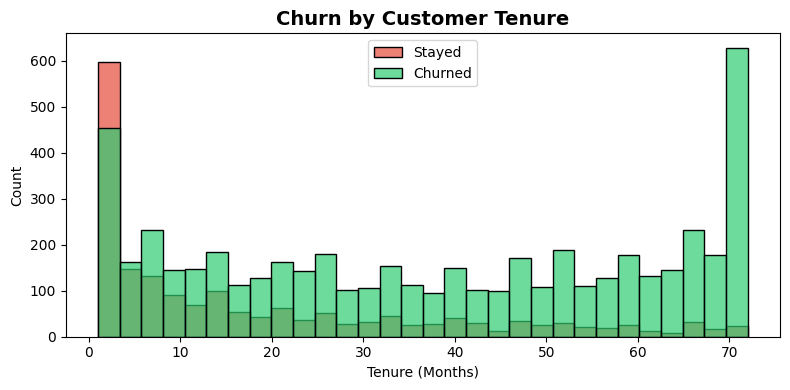

Average tenure - Stayed: 37.7 months
Average tenure - Churned: 18.0 months


In [7]:
# Tenure vs churn
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', 
             bins=30, palette=['#2ecc71','#e74c3c'], alpha=0.7)
plt.title('Churn by Customer Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150)
plt.show()

# Average tenure
print("Average tenure - Stayed:", round(df[df['Churn']==0]['tenure'].mean(),1), "months")
print("Average tenure - Churned:", round(df[df['Churn']==1]['tenure'].mean(),1), "months")
# "Customers who leave have been with the company only 18 months on average — "
# "customers who stay have been there 37 months. The first 18 months is the danger zone —"
# " if you can keep a customer past that, they'll likely stay forever."

C:\Users\Admin\AppData\Local\Temp\ipykernel_2528\3581032032.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df,


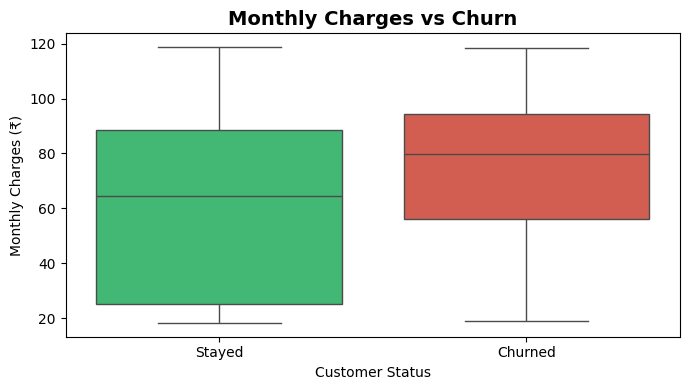

Average Monthly Charge - Stayed: 61.31
Average Monthly Charge - Churned: 74.44


In [ ]:
# Monthly charges vs churn
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette=['#2ecc71','#e74c3c'])
plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Monthly Charges (₹)')
plt.tight_layout()
plt.savefig('churn_by_charges.png', dpi=150)
plt.show()

# Print averages
print("Average Monthly Charge - Stayed:", round(df[df['Churn']==0]['MonthlyCharges'].mean(),2))
print("Average Monthly Charge - Churned:", round(df[df['Churn']==1]['MonthlyCharges'].mean(),2))

"Customers who leave pay ₹74/month on average vs ₹61 for those who stay. Higher bills make customers look for cheaper alternatives — pricing is a key churn trigger."


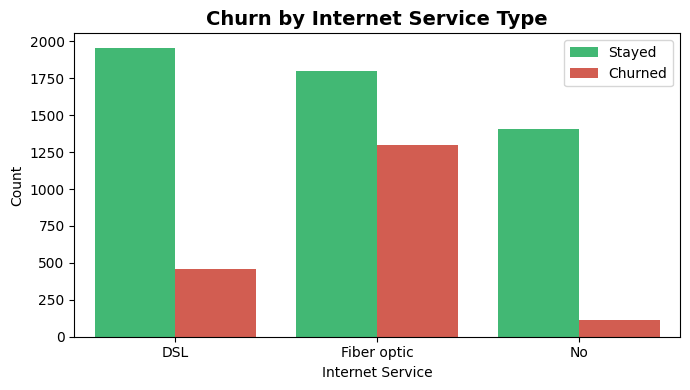

InternetService
DSL            18.998344
Fiber optic    41.892765
No              7.434211
Name: Churn, dtype: float64


In [9]:
# Internet service vs churn
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', hue='Churn', data=df,
              palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Internet Service Type', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_internet.png', dpi=150)
plt.show()

# Print churn rate by internet service
print(df.groupby('InternetService')['Churn'].mean() * 100)
# "Fiber optic customers churn at 42% — more than double DSL customers. "
# "Despite paying more for faster internet, they're the most unhappy — "
# "likely due to service quality or pricing issues."

C:\Users\Admin\AppData\Local\Temp\ipykernel_2528\956822727.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0,0], x='Churn', data=df,


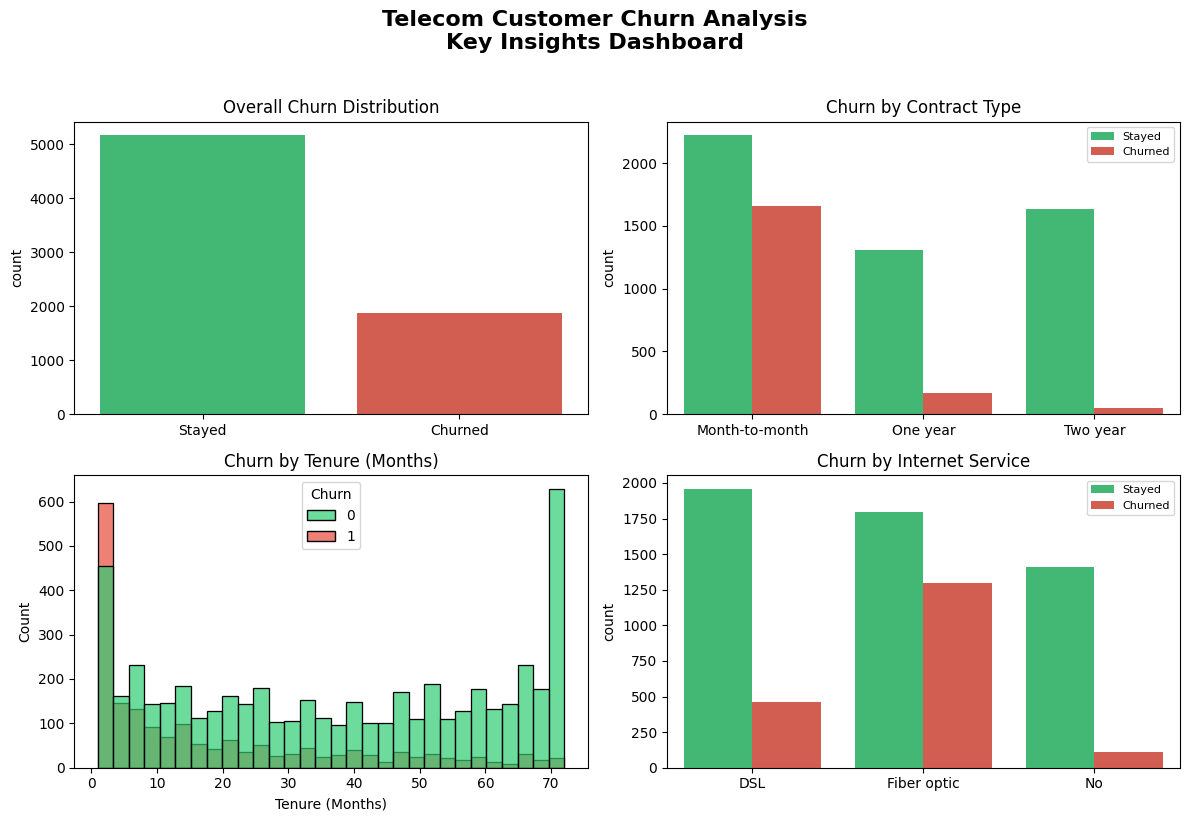

Dashboard saved!


In [ ]:
# Final summary - all 4 key insights in one chart
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Telecom Customer Churn Analysis\nKey Insights Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)

# Chart 1 - Churn Distribution
sns.countplot(ax=axes[0,0], x='Churn', data=df, 
              palette=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Overall Churn Distribution')
axes[0,0].set_xticks([0,1])
axes[0,0].set_xticklabels(['Stayed', 'Churned'])
axes[0,0].set_xlabel('')

# Chart 2 - Contract Type
sns.countplot(ax=axes[0,1], x='Contract', hue='Churn', data=df,
              palette=['#2ecc71','#e74c3c'])
axes[0,1].set_title('Churn by Contract Type')
axes[0,1].legend(['Stayed','Churned'], fontsize=8)
axes[0,1].set_xlabel('')

# Chart 3 - Tenure
sns.histplot(ax=axes[1,0], data=df, x='tenure', hue='Churn',
             bins=30, palette=['#2ecc71','#e74c3c'], alpha=0.7)
axes[1,0].set_title('Churn by Tenure (Months)')
axes[1,0].set_xlabel('Tenure (Months)')

# Chart 4 - Internet Service
sns.countplot(ax=axes[1,1], x='InternetService', hue='Churn', data=df,
              palette=['#2ecc71','#e74c3c'])
axes[1,1].set_title('Churn by Internet Service')
axes[1,1].legend(['Stayed','Churned'], fontsize=8)
axes[1,1].set_xlabel('')

plt.tight_layout()
plt.savefig('churn_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")
# This is the final summary dashboard showing all 4 churn factors in one view

In [11]:
# Business Recommendations
recommendations = {
    "Finding 1": "26.58% churn rate — 1 in 4 customers leaving",
    "Recommendation 1": "Launch a loyalty program in first 18 months to retain new customers",
    
    "Finding 2": "Month-to-month contracts churn 15x more",
    "Recommendation 2": "Offer discounts to move customers from monthly to annual contracts",
    
    "Finding 3": "Fiber optic churn at 42%",
    "Recommendation 3": "Investigate service quality issues and introduce retention pricing for fiber users",
    
    "Finding 4": "High monthly charges drive churn",
    "Recommendation 4": "Introduce loyalty discounts for customers paying above ₹70/month"
}

for key, value in recommendations.items():
    print(f"{key}: {value}")
    print()

Finding 1: 26.58% churn rate — 1 in 4 customers leaving

Recommendation 1: Launch a loyalty program in first 18 months to retain new customers

Finding 2: Month-to-month contracts churn 15x more

Recommendation 2: Offer discounts to move customers from monthly to annual contracts

Finding 3: Fiber optic churn at 42%

Recommendation 3: Investigate service quality issues and introduce retention pricing for fiber users

Finding 4: High monthly charges drive churn

Recommendation 4: Introduce loyalty discounts for customers paying above ₹70/month



In [12]:
# Business Impact Calculation
avg_monthly_revenue = df['MonthlyCharges'].mean()
churned_customers = df['Churn'].sum()
monthly_revenue_lost = avg_monthly_revenue * churned_customers
annual_revenue_lost = monthly_revenue_lost * 12

print("=" * 45)
print("       BUSINESS IMPACT SUMMARY")
print("=" * 45)
print(f"Total Customers Analysed  : {len(df):,}")
print(f"Customers Churned         : {churned_customers:,}")
print(f"Average Monthly Charge    : ${avg_monthly_revenue:.2f}")
print(f"Monthly Revenue Lost      : ${monthly_revenue_lost:,.2f}")
print(f"Annual Revenue Lost       : ${annual_revenue_lost:,.2f}")
print("=" * 45)
print("Top 3 Churn Risk Factors:")
print("  1. Month-to-month contracts (42.71% churn)")
print("  2. Fiber optic service     (41.89% churn)")
print("  3. High monthly charges    (Avg $74 vs $61)")
print("=" * 45)

       BUSINESS IMPACT SUMMARY
Total Customers Analysed  : 7,032
Customers Churned         : 1,869
Average Monthly Charge    : $64.80
Monthly Revenue Lost      : $121,107.85
Annual Revenue Lost       : $1,453,294.21
Top 3 Churn Risk Factors:
  1. Month-to-month contracts (42.71% churn)
  2. Fiber optic service     (41.89% churn)
  3. High monthly charges    (Avg $74 vs $61)


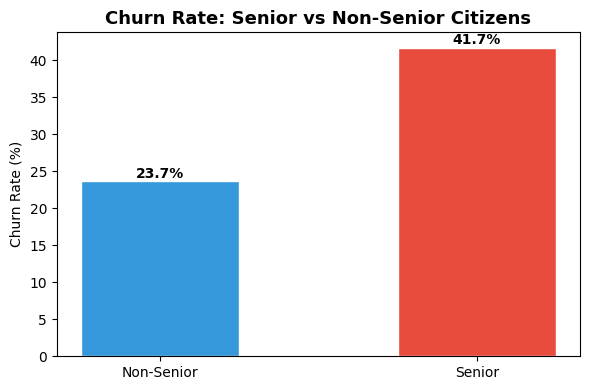

Senior citizen churn rate: 41.68%
Non-senior churn rate: 23.65%


In [13]:
# Senior citizen churn analysis
plt.figure(figsize=(6,4))
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean() * 100
bars = plt.bar(['Non-Senior', 'Senior'], senior_churn.values,
               color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
plt.title('Churn Rate: Senior vs Non-Senior Citizens', 
          fontweight='bold', fontsize=13)
plt.ylabel('Churn Rate (%)')
for bar, val in zip(bars, senior_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('churn_senior.png', dpi=150)
plt.show()
print(f"Senior citizen churn rate: {senior_churn[1]:.2f}%")
print(f"Non-senior churn rate: {senior_churn[0]:.2f}%")

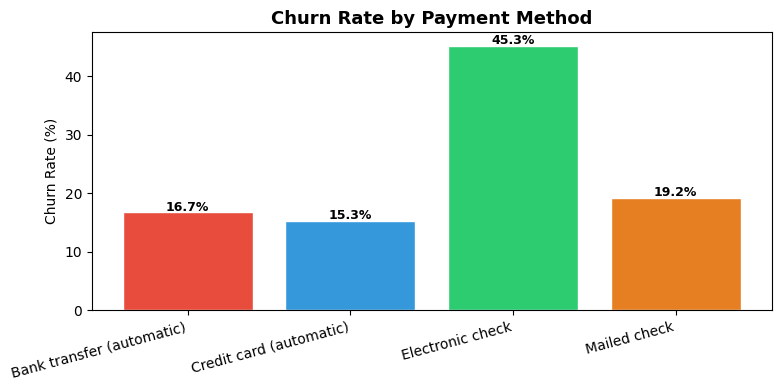

PaymentMethod
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Electronic check             45.285412
Mailed check                 19.201995
Name: Churn, dtype: float64


In [14]:
# Payment method vs churn
plt.figure(figsize=(8,4))
payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100
colors_list = ['#e74c3c', '#3498db', '#2ecc71', '#e67e22']
bars = plt.bar(payment_churn.index, payment_churn.values,
               color=colors_list, edgecolor='white')
plt.title('Churn Rate by Payment Method', fontweight='bold', fontsize=13)
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, payment_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_payment.png', dpi=150)
plt.show()
print(payment_churn)


In [15]:
# Project Summary
print("=" * 50)
print("   TELECOM CUSTOMER CHURN ANALYSIS")
print("   Complete Project Summary")
print("=" * 50)
print()
print("DATASET")
print(f"  Total Records     : {len(df):,} customers")
print(f"  Total Features    : {df.shape[1]} columns")
print()
print("KEY METRICS")
print(f"  Overall Churn Rate: 26.58%")
print(f"  Customers Churned : 1,869")
print(f"  Customers Stayed  : 5,163")
print(f"  Annual Revenue Lost: $1.4M (estimated)")
print()
print("TOP CHURN RISK FACTORS")
print("  1. Month-to-month contracts  → 42.71% churn")
print("  2. Fiber optic service       → 41.89% churn")
print("  3. New customers <18 months  → Highest risk")
print("  4. High monthly charges >$70 → More likely to leave")
print()
print("CHARTS GENERATED")
print("   churn_distribution.png")
print("   churn_by_contract.png")
print("   churn_by_tenure.png")
print("   churn_by_charges.png")
print("   churn_dashboard.png")
print("   churn_senior.png")
print("   churn_payment.png")
print()
print("TOOLS USED")
print("  Python | Pandas | Matplotlib | Seaborn")
print("=" * 50)
print("Project by: Dhruthi M Kashyap")
print("GitHub: github.com/Dhruthi-Kashyap")
print("=" * 50)

   TELECOM CUSTOMER CHURN ANALYSIS
   Complete Project Summary

DATASET
  Total Records     : 7,032 customers
  Total Features    : 21 columns

KEY METRICS
  Overall Churn Rate: 26.58%
  Customers Churned : 1,869
  Customers Stayed  : 5,163
  Annual Revenue Lost: $1.4M (estimated)

TOP CHURN RISK FACTORS
  1. Month-to-month contracts  → 42.71% churn
  2. Fiber optic service       → 41.89% churn
  3. New customers <18 months  → Highest risk
  4. High monthly charges >$70 → More likely to leave

CHARTS GENERATED
   churn_distribution.png
   churn_by_contract.png
   churn_by_tenure.png
   churn_by_charges.png
   churn_dashboard.png
   churn_senior.png
   churn_payment.png

TOOLS USED
  Python | Pandas | Matplotlib | Seaborn
Project by: Dhruthi M Kashyap
GitHub: github.com/Dhruthi-Kashyap
